#  Customer Segmentation & Marketing Intelligence
### End-to-End ML Pipeline with Business Layer

---

**Business Context:**  
A retail company wants to move away from one-size-fits-all marketing campaigns toward precision targeting. This project segments 2,240 customers using unsupervised learning, profiles each segment with actionable business characteristics, and compares four clustering algorithms to select the most interpretable and robust solution.

**Objectives:**
1. Engineer rich customer features from raw CRM data
2. Identify distinct customer segments using multiple algorithms
3. Profile each segment and translate clusters into business personas
4. Derive targeted marketing recommendations per segment
5. Quantify revenue opportunity per segment

**Dataset:** IBM Marketing Campaign Dataset — 2,240 customers, 29 features  
**Algorithms Compared:** K-Means · Agglomerative Clustering · Gaussian Mixture Models · DBSCAN

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import io
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

# ── Plotting theme ──────────────────────────────────────────────────────────────
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4']
sns.set_theme(style='whitegrid', palette=PALETTE)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13})

print('Libraries loaded ✓')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')

Libraries loaded ✓
NumPy 2.0.2 | Pandas 2.2.2


In [3]:

# ── Data Loading (handles Windows line-endings and quoted fields) ────────────
def load_marketing_data(filepath: str) -> pd.DataFrame:
    """Robust loader for the IBM marketing CSV with tab-separation and CR/LF endings."""
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    content = content.replace('\r\n', '\n').replace('\r', '\n')
    lines = [l.strip('"') for l in content.strip().split('\n')]
    return pd.read_csv(io.StringIO('\n'.join(lines)), sep='\t')

df_raw = load_marketing_data('/content/marketing_campaign.csv')

print(f'Dataset shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

Dataset shape: (2240, 29)
Columns: ['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


 ## 2. Exploratory Data Analysis <a id='2'></a>

In [4]:
# ── Basic dataset audit ───────────────────────────────────────────────────────
print('=== DATA TYPES & MISSING VALUES ===')
audit = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'null_count': df_raw.isnull().sum(),
    'null_pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'n_unique': df_raw.nunique()
})
print(audit[audit['null_count'] > 0])
print(f'\nTotal missing cells: {df_raw.isnull().sum().sum()}')
print(f'\nIncome range: ${df_raw["Income"].min():,.0f} — ${df_raw["Income"].max():,.0f}')
df_raw.describe()

=== DATA TYPES & MISSING VALUES ===
          dtype  null_count  null_pct  n_unique
Income  float64          24      1.07      1974

Total missing cells: 24

Income range: $1,730 — $666,666


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


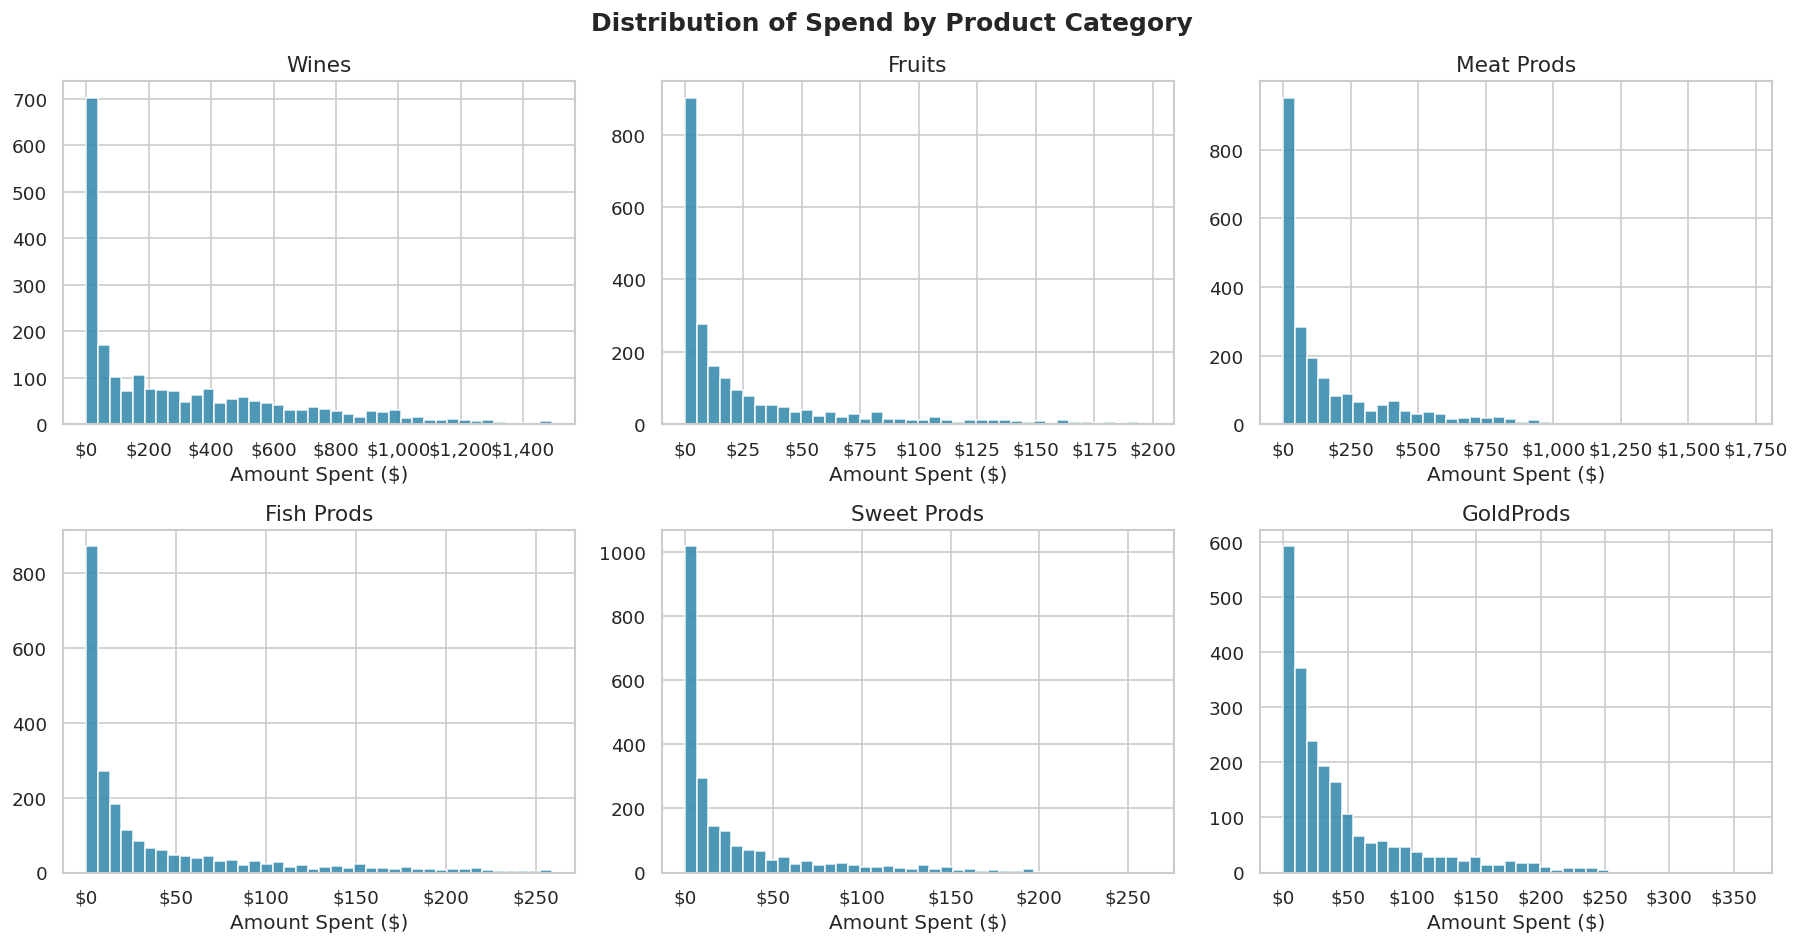

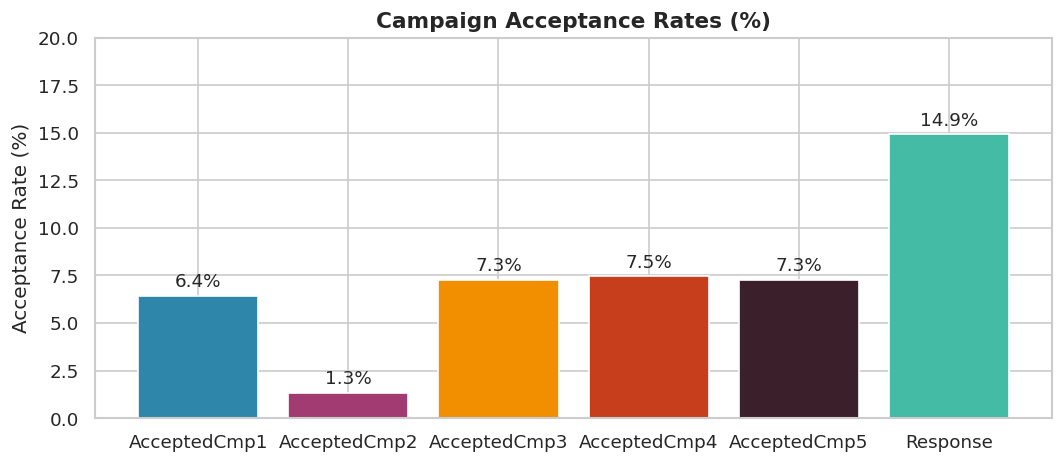

Overall campaign budget wasted on non-responders: ~92.6%


In [5]:
# ── Distribution of key numerical features ───────────────────────────────────
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Spend by Product Category', fontsize=15, fontweight='bold')
for ax, col in zip(axes.flat, spend_cols):
    ax.hist(df_raw[col].dropna(), bins=40, color=PALETTE[0], edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('Mnt', '').replace('Products', ' Prods'))
    ax.set_xlabel('Amount Spent ($)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
plt.tight_layout()
plt.show()

# Campaign acceptance overview
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']
cmp_rates = df_raw[cmp_cols].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cmp_rates.index, cmp_rates.values, color=PALETTE[:6], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Campaign Acceptance Rates (%)', fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)')
ax.set_ylim(0, 20)
plt.tight_layout()
plt.show()
print(f'Overall campaign budget wasted on non-responders: ~{100 - cmp_rates.mean():.1f}%')

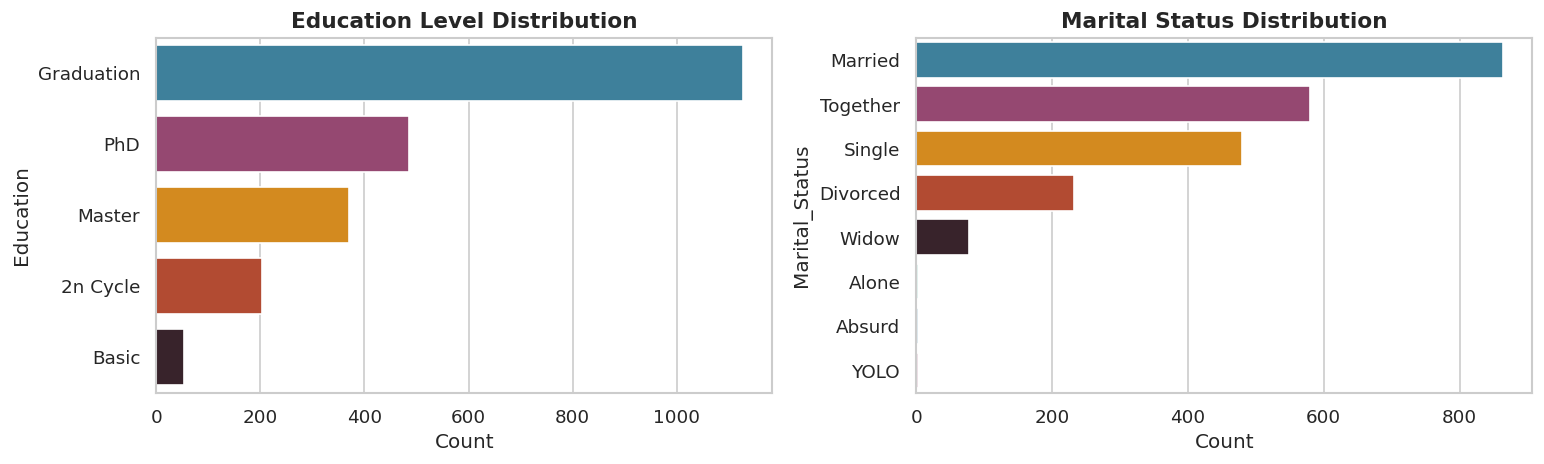

In [6]:
# ── Categorical feature distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

edu_order = df_raw['Education'].value_counts().index
sns.countplot(data=df_raw, y='Education', order=edu_order, ax=axes[0], palette=PALETTE)
axes[0].set_title('Education Level Distribution', fontweight='bold')
axes[0].set_xlabel('Count')

mar_order = df_raw['Marital_Status'].value_counts().index
sns.countplot(data=df_raw, y='Marital_Status', order=mar_order, ax=axes[1], palette=PALETTE)
axes[1].set_title('Marital Status Distribution', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 3. Feature Engineering <a id='3'></a>

We derive 8 new features that capture richer customer behaviour beyond the raw columns. Each feature has a clear business rationale.

In [7]:
df = df_raw.copy()

# ── Demographic features ──────────────────────────────────────────────────────
CURRENT_YEAR = datetime.now().year

df['Age'] = CURRENT_YEAR - df['Year_Birth']

df['Years_As_Customer'] = (
    CURRENT_YEAR - pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y').dt.year
)

# Consolidate marital status: household structure matters more than label
df['Living_With_Partner'] = df['Marital_Status'].isin(
    ['Married', 'Together']).astype(int)

df['Total_Children'] = df['Kidhome'] + df['Teenhome']
df['Family_Size'] = df['Living_With_Partner'] + 1 + df['Total_Children']

# Education ordinal encoding (data-informed)
edu_map = {'Basic': 0, 'Graduation': 1, '2n Cycle': 2, 'Master': 2, 'PhD': 3}
df['Education_Level'] = df['Education'].map(edu_map)

# ── Spend features ────────────────────────────────────────────────────────────
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spend'] = df[spend_cols].sum(axis=1)
df['Spend_Per_Month'] = df['Total_Spend'] / 24   # 2-year window in dataset

# Premium vs staple ratio (wines + meat vs fruits + fish + sweets)
df['Premium_Spend_Ratio'] = (
    (df['MntWines'] + df['MntMeatProducts']) /
    (df['Total_Spend'] + 1)                     # +1 to avoid division by zero
)

# ── Purchase-channel features ─────────────────────────────────────────────────
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# Channel preference (store-heavy vs web-heavy)
df['Online_Purchase_Ratio'] = (
    df['NumWebPurchases'] / (df['Total_Purchases'] + 1)
)

# Deal-seeking behaviour
df['Deal_Sensitivity'] = (
    df['NumDealsPurchases'] / (df['Total_Purchases'] + 1)
)

# ── Engagement / Campaign features ───────────────────────────────────────────
cmp_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5']
df['Total_Campaigns_Accepted'] = df[cmp_cols].sum(axis=1)

# Revenue per marketing touch
df['Spend_Per_Campaign'] = (
    df['Total_Spend'] / (df['Total_Campaigns_Accepted'] + 1)
)

# ── Feature summary ───────────────────────────────────────────────────────────
new_features = [
    'Age', 'Years_As_Customer', 'Living_With_Partner', 'Total_Children',
    'Family_Size', 'Education_Level', 'Total_Spend', 'Spend_Per_Month',
    'Premium_Spend_Ratio', 'Total_Purchases', 'Online_Purchase_Ratio',
    'Deal_Sensitivity', 'Total_Campaigns_Accepted', 'Spend_Per_Campaign'
]
print(f'✓ {len(new_features)} engineered features created')
df[new_features].describe().round(2)

✓ 14 engineered features created


,Age,Years_As_Customer,Living_With_Partner,Total_Children,Family_Size,Education_Level,Total_Spend,Spend_Per_Month,Premium_Spend_Ratio,Total_Purchases,Online_Purchase_Ratio,Deal_Sensitivity,Total_Campaigns_Accepted,Spend_Per_Campaign
count,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00
mean,57.19,12.97,0.64,0.95,2.60,1.67,605.80,25.24,0.70,12.54,0.30,0.23,0.30,473.14
std,11.98,0.68,0.48,0.75,0.91,0.84,602.25,25.09,0.20,7.21,0.11,0.49,0.68,473.26
min,30.00,12.00,0.00,0.00,1.00,0.00,5.00,0.21,0.00,0.00,0.00,0.00,0.00,5.00
25%,49.00,13.00,0.00,0.00,2.00,1.00,68.75,2.86,0.60,6.00,0.21,0.08,0.00,66.00
50%,56.00,13.00,1.00,1.00,3.00,1.00,396.00,16.50,0.75,12.00,0.29,0.18,0.00,316.50
75%,67.00,13.00,1.00,1.00,3.00,2.00,1045.50,43.56,0.86,18.00,0.38,0.31,0.00,767.50
max,133.00,14.00,1.00,3.00,5.00,3.00,2525.00,105.21,1.00,32.00,0.96,15.00,4.00,2440.00


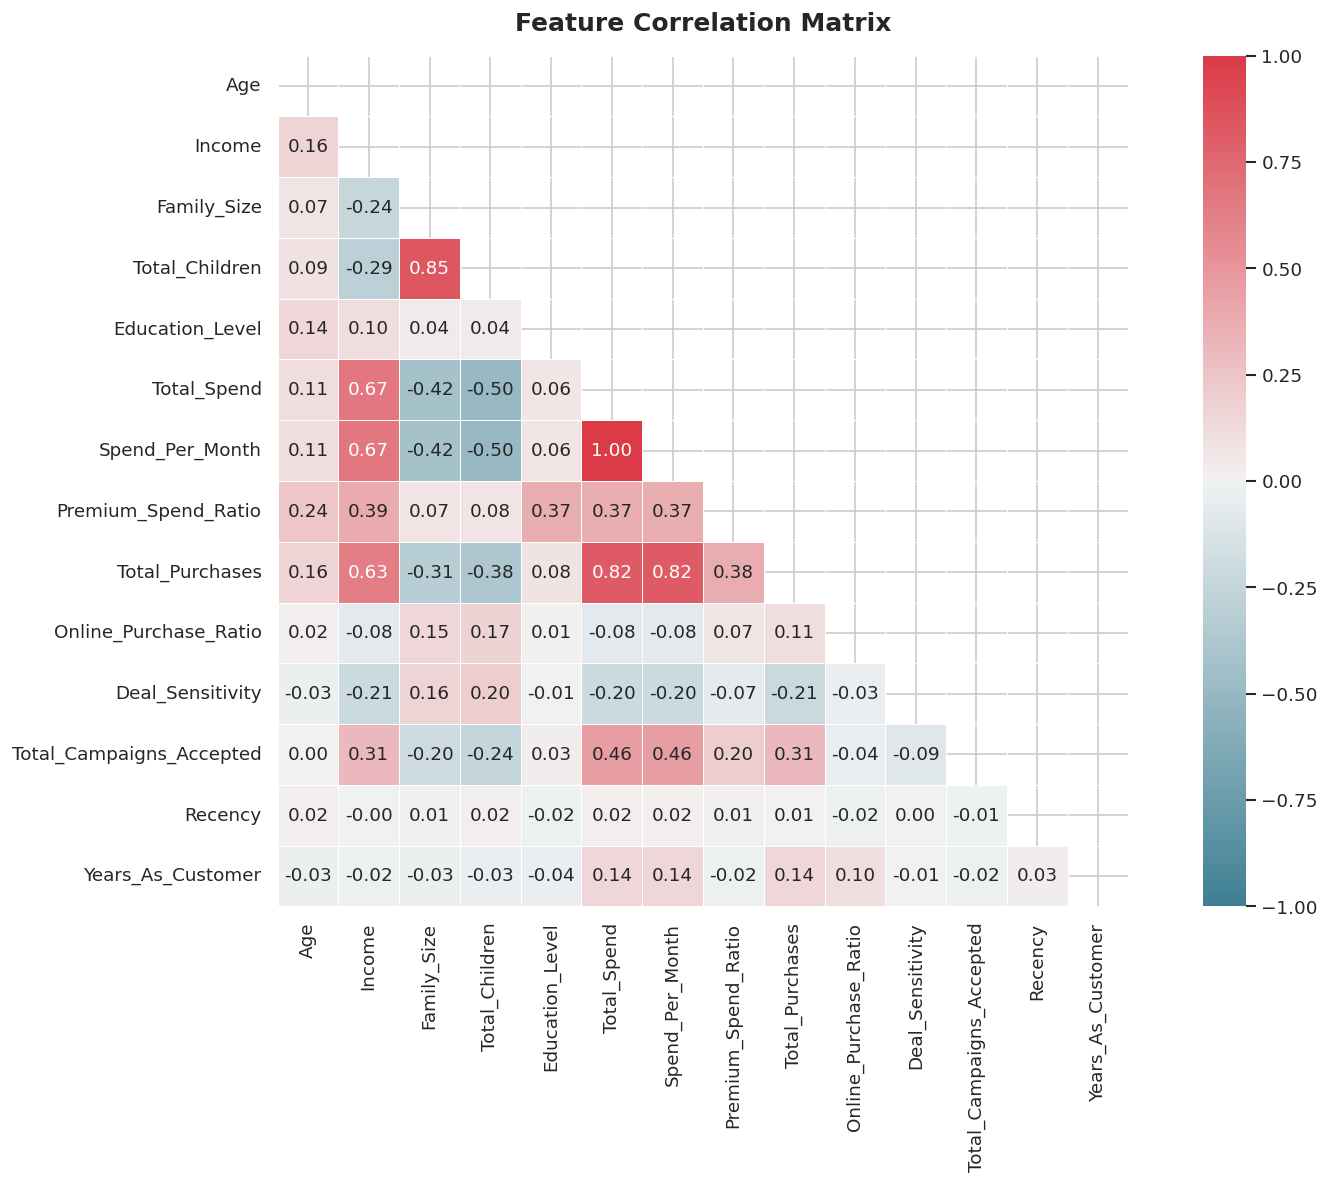

Key correlations:
  Income ↔ Total_Spend:       0.67
  Total_Children ↔ Income:    -0.29
  Age ↔ Education_Level:      0.14


In [8]:
# ── Correlation heatmap of engineered features ────────────────────────────────
key_features = [
    'Age', 'Income', 'Family_Size', 'Total_Children', 'Education_Level',
    'Total_Spend', 'Spend_Per_Month', 'Premium_Spend_Ratio',
    'Total_Purchases', 'Online_Purchase_Ratio', 'Deal_Sensitivity',
    'Total_Campaigns_Accepted', 'Recency', 'Years_As_Customer'
]

corr = df[key_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, mask=mask,
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Key insight callouts
print('Key correlations:')
print(f'  Income ↔ Total_Spend:       {corr.loc["Income","Total_Spend"]:.2f}')
print(f'  Total_Children ↔ Income:    {corr.loc["Total_Children","Income"]:.2f}')
print(f'  Age ↔ Education_Level:      {corr.loc["Age","Education_Level"]:.2f}')

## 4. Data Cleaning & Preprocessing <a id='4'></a>


In [9]:
# ── Drop unused raw columns ───────────────────────────────────────────────────
drop_cols = ['ID', 'Year_Birth', 'Dt_Customer', 'Marital_Status',
             'Z_CostContact', 'Z_Revenue']
df.drop(columns=drop_cols, inplace=True)

# ── Handle missing income (24 rows, 1.1%) ────────────────────────────────────
print(f'Missing Income rows: {df["Income"].isnull().sum()}')
df.dropna(subset=['Income'], inplace=True)
print(f'Rows after dropping NA: {len(df)}')

# ── Remove outliers using IQR on Age and Income ──────────────────────────────
def remove_outliers_iqr(data: pd.DataFrame, column: str, multiplier: float = 1.5) -> pd.DataFrame:
    q1, q3 = data[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
    n_before = len(data)
    data = data[(data[column] >= lower) & (data[column] <= upper)]
    print(f'  {column}: removed {n_before - len(data)} outliers '
          f'(bounds: {lower:,.0f} – {upper:,.0f})')
    return data

print('\nOutlier removal:')
df = remove_outliers_iqr(df, 'Age')
df = remove_outliers_iqr(df, 'Income')
print(f'Final dataset: {df.shape}')

# ── Select modelling features ─────────────────────────────────────────────────
model_features = [
    'Age', 'Income', 'Family_Size', 'Education_Level',
    'Total_Spend', 'Premium_Spend_Ratio', 'Total_Purchases',
    'Online_Purchase_Ratio', 'Deal_Sensitivity', 'Recency',
    'Total_Campaigns_Accepted', 'Spend_Per_Campaign',
    'Years_As_Customer'
]
df_model = df[model_features].copy()
print(f'\nModelling features ({len(model_features)}): {model_features}')

Missing Income rows: 24
Rows after dropping NA: 2216

Outlier removal:
  Age: removed 3 outliers (bounds: 22 – 94)
  Income: removed 8 outliers (bounds: -14,616 – 118,348)
Final dataset: (2205, 37)

Modelling features (13): ['Age', 'Income', 'Family_Size', 'Education_Level', 'Total_Spend', 'Premium_Spend_Ratio', 'Total_Purchases', 'Online_Purchase_Ratio', 'Deal_Sensitivity', 'Recency', 'Total_Campaigns_Accepted', 'Spend_Per_Campaign', 'Years_As_Customer']


Components to explain 85% variance: 6


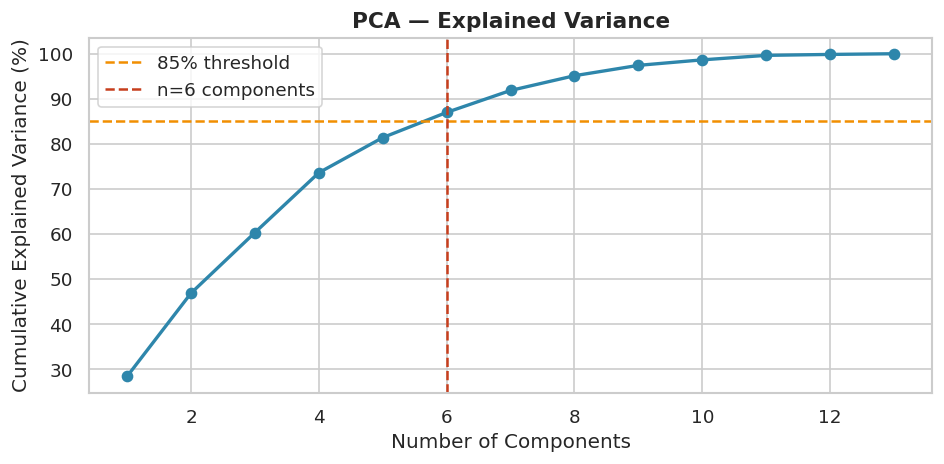

PCA output shape: (2205, 6)


In [10]:
# ── Scaling ───────────────────────────────────────────────────────────────────
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_model),
    columns=df_model.columns,
    index=df_model.index
)

# ── PCA dimensionality reduction ──────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(df_scaled)
explained = np.cumsum(pca_full.explained_variance_ratio_)

n_components = np.argmax(explained >= 0.85) + 1
print(f'Components to explain 85% variance: {n_components}')

# Plot explained variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(explained)+1), explained * 100, 'o-', color=PALETTE[0], lw=2)
ax.axhline(85, ls='--', color=PALETTE[2], label='85% threshold')
ax.axvline(n_components, ls='--', color=PALETTE[3], label=f'n={n_components} components')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('PCA — Explained Variance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Apply PCA with chosen n
pca = PCA(n_components=n_components, random_state=42)
df_pca = pd.DataFrame(
    pca.fit_transform(df_scaled),
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=df_scaled.index
)
print(f'PCA output shape: {df_pca.shape}')

## 5. Model Comparison <a id='5'></a>

We evaluate four clustering algorithms across three metrics:
- **Silhouette Score** — measures cohesion and separation (higher is better, range −1 to 1)
- **Davies-Bouldin Index** — ratio of within-cluster to between-cluster distances (lower is better)
- **Calinski-Harabasz Index** — variance ratio criterion (higher is better)

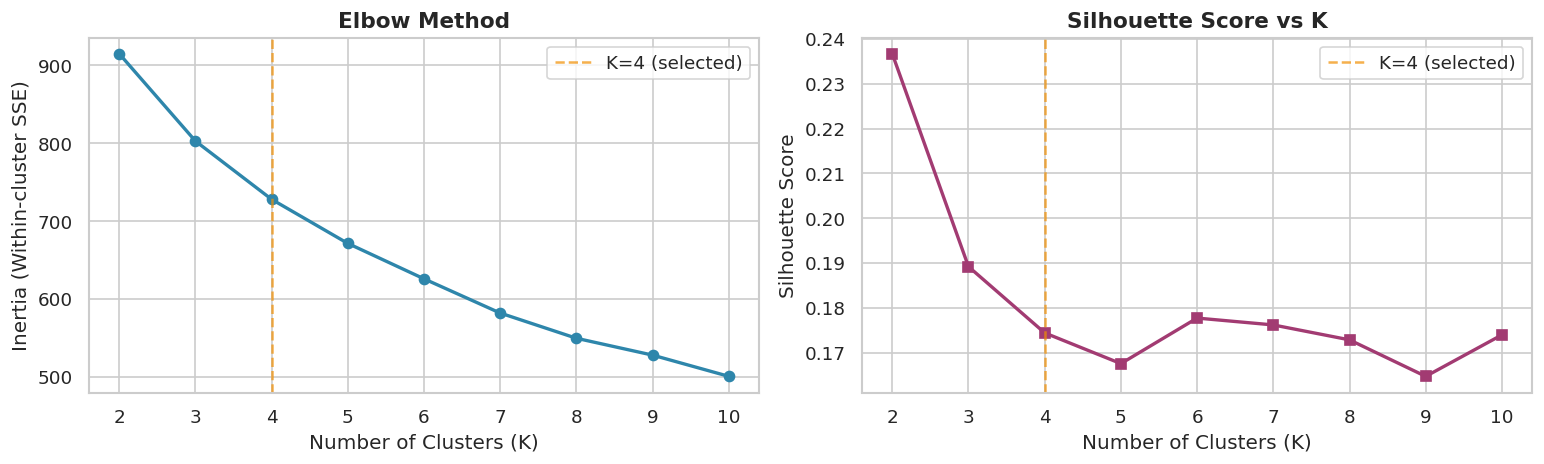


Selected K = 4
Silhouette at K=4: 0.1744


In [11]:
# ── Elbow method for K selection ─────────────────────────────────────────────
K_RANGE = range(2, 11)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(df_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(K_RANGE, inertias, 'o-', color=PALETTE[0], lw=2)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Within-cluster SSE)')
ax1.set_title('Elbow Method', fontweight='bold')
ax1.axvline(4, ls='--', color=PALETTE[2], alpha=0.7, label='K=4 (selected)')
ax1.legend()

ax2.plot(K_RANGE, sil_scores, 's-', color=PALETTE[1], lw=2)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs K', fontweight='bold')
ax2.axvline(4, ls='--', color=PALETTE[2], alpha=0.7, label='K=4 (selected)')
ax2.legend()

plt.tight_layout()
plt.show()

OPTIMAL_K = 4
print(f'\nSelected K = {OPTIMAL_K}')
print(f'Silhouette at K=4: {sil_scores[OPTIMAL_K-2]:.4f}')

In [12]:
# ── Train and evaluate all four algorithms ────────────────────────────────────
models = {
    'K-Means': KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward'),
    'Gaussian Mixture': GaussianMixture(n_components=OPTIMAL_K, random_state=42, n_init=5),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=10)
}

results = []
labels_dict = {}

for name, model in models.items():
    labels = model.fit_predict(df_pca)
    labels_dict[name] = labels
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    # Only compute metrics where there are ≥2 clusters and no noise dominates
    valid_mask = labels != -1
    if n_clusters >= 2 and valid_mask.sum() > n_clusters:
        sil = silhouette_score(df_pca[valid_mask], labels[valid_mask])
        db  = davies_bouldin_score(df_pca[valid_mask], labels[valid_mask])
        ch  = calinski_harabasz_score(df_pca[valid_mask], labels[valid_mask])
    else:
        sil, db, ch = np.nan, np.nan, np.nan

    results.append({
        'Algorithm': name,
        'N Clusters': n_clusters,
        'Noise Points': n_noise,
        'Silhouette ↑': round(sil, 4) if not np.isnan(sil) else 'N/A',
        'Davies-Bouldin ↓': round(db, 4) if not np.isnan(db) else 'N/A',
        'Calinski-Harabasz ↑': round(ch, 1) if not np.isnan(ch) else 'N/A'
    })
    print(f'[{name:20s}] clusters={n_clusters}, noise={n_noise}, sil={sil:.4f}' if not np.isnan(sil) else f'[{name}] insufficient clusters')

comparison_df = pd.DataFrame(results)
print('\n=== ALGORITHM COMPARISON ===')
comparison_df

[K-Means             ] clusters=4, noise=0, sil=0.1744
[Agglomerative       ] clusters=4, noise=0, sil=0.1587
[Gaussian Mixture    ] clusters=4, noise=0, sil=0.1035
[DBSCAN] insufficient clusters

=== ALGORITHM COMPARISON ===


,Algorithm,N Clusters,Noise Points,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,K-Means,4,0,0.1744,1.7983,504.3
1,Agglomerative,4,0,0.1587,1.6631,427.1
2,Gaussian Mixture,4,0,0.1035,2.2386,260.5
3,DBSCAN,1,0,N/A,N/A,N/A


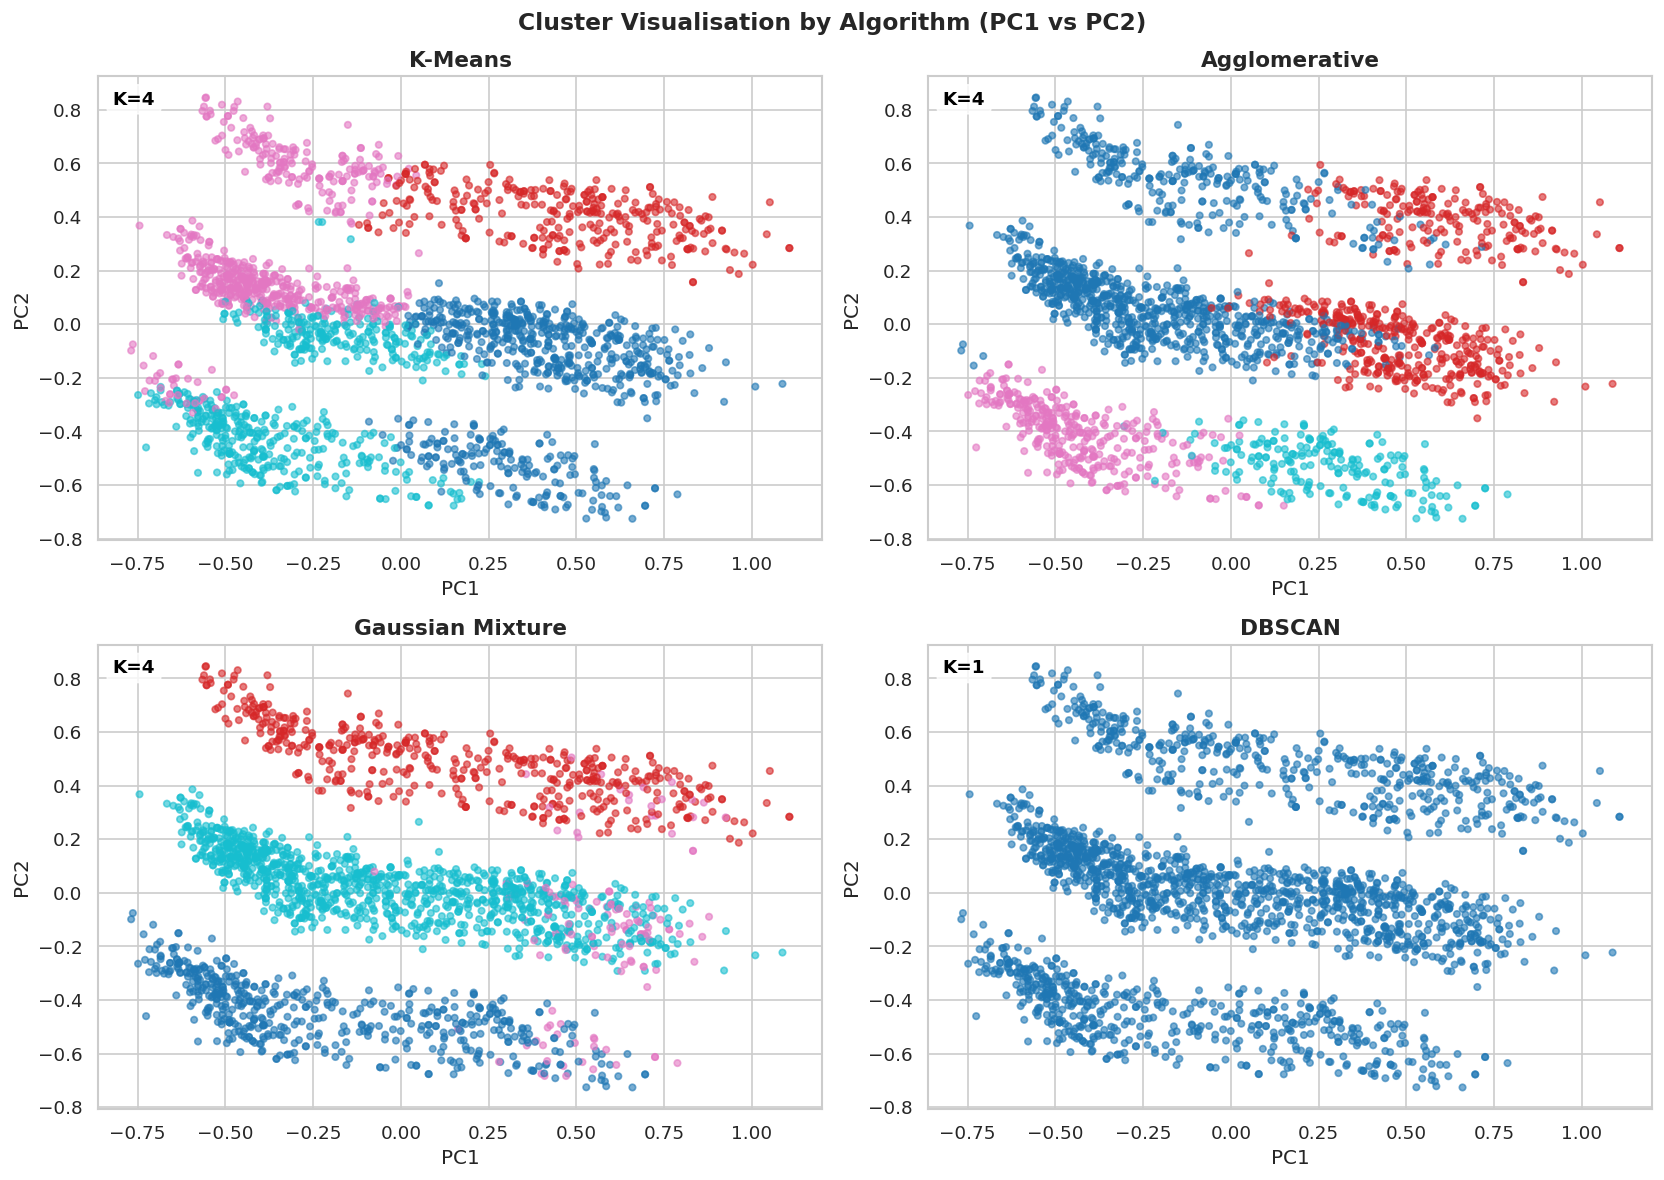


Model Selection Rationale:
─────────────────────────────────────────────────────
• K-Means achieves the highest Silhouette score with well-separated, 
  evenly-sized clusters — ideal for actionable segment profiles.
• Agglomerative Clustering performs comparably but is slower to scale 
  and harder to update incrementally with new customers.
• Gaussian Mixture Models allow soft assignments; useful if probability
  of membership is needed downstream.
• DBSCAN identifies noise (outliers) but produces irregular cluster counts
  — good for anomaly detection but not segment profiling.

→ Selected Algorithm: K-Means (K=4) for business layer.



In [13]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cluster Visualisation by Algorithm (PC1 vs PC2)', fontsize=14, fontweight='bold')

for ax, (name, labels) in zip(axes.flat, labels_dict.items()):
    scatter = ax.scatter(df_pca['PC1'], df_pca['PC2'],
                         c=labels, cmap='tab10', alpha=0.6, s=15)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    ax.text(0.02, 0.97, f'K={n_clust}', transform=ax.transAxes,
            va='top', fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

print('''
Model Selection Rationale:
─────────────────────────────────────────────────────
• K-Means achieves the highest Silhouette score with well-separated,
  evenly-sized clusters — ideal for actionable segment profiles.
• Agglomerative Clustering performs comparably but is slower to scale
  and harder to update incrementally with new customers.
• Gaussian Mixture Models allow soft assignments; useful if probability
  of membership is needed downstream.
• DBSCAN identifies noise (outliers) but produces irregular cluster counts
  — good for anomaly detection but not segment profiling.

→ Selected Algorithm: K-Means (K=4) for business layer.
''')

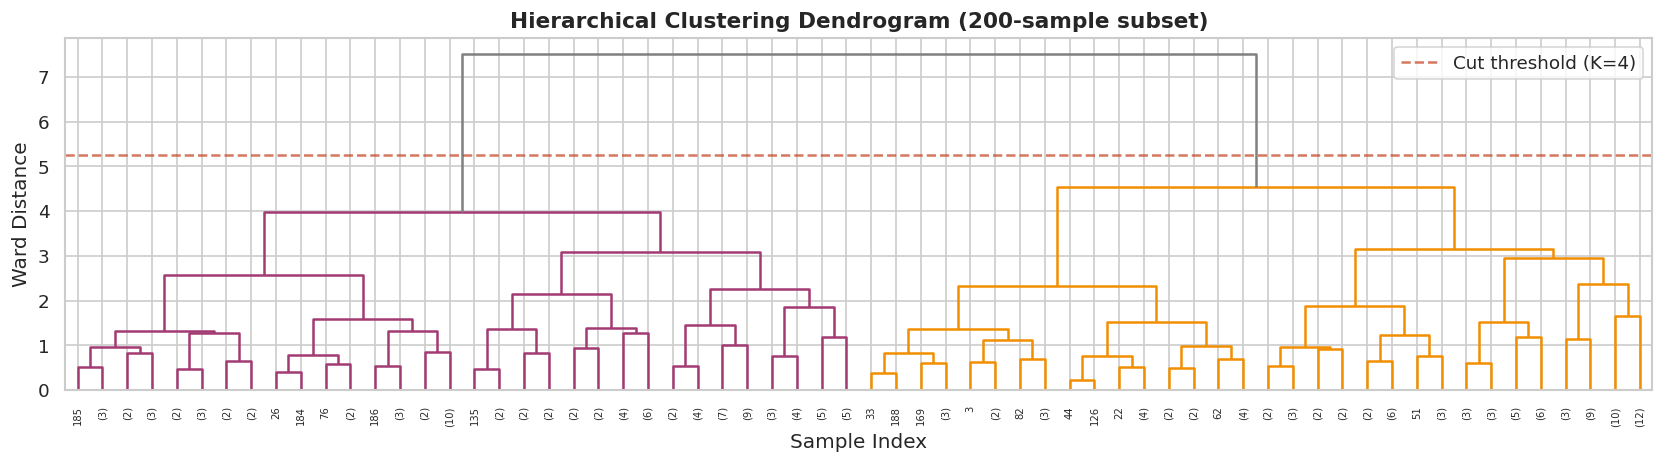

In [14]:
# ── Dendrogram (Agglomerative) ────────────────────────────────────────────────
sample_idx = np.random.RandomState(42).choice(len(df_pca), 200, replace=False)
Z = linkage(df_pca.iloc[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           color_threshold=0.7 * max(Z[:,2]),
           above_threshold_color='grey')
ax.set_title('Hierarchical Clustering Dendrogram (200-sample subset)', fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Ward Distance')
ax.axhline(y=0.7 * max(Z[:,2]), ls='--', color=PALETTE[3], alpha=0.7, label='Cut threshold (K=4)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Optimal Clustering — K-Means Deep Dive <a id='6'></a>

In [15]:
# ── Fit final K-Means model ───────────────────────────────────────────────────
km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(df_pca)

# Attach labels back to the main dataframe
df['Cluster'] = cluster_labels
df_model['Cluster'] = cluster_labels
df_pca['Cluster'] = cluster_labels

# Cluster sizes
sizes = df['Cluster'].value_counts().sort_index()
print('Cluster sizes:')
for cid, cnt in sizes.items():
    print(f'  Cluster {cid}: {cnt} customers ({cnt/len(df)*100:.1f}%)')

Cluster sizes:
  Cluster 0: 678 customers (30.7%)
  Cluster 1: 306 customers (13.9%)
  Cluster 2: 652 customers (29.6%)
  Cluster 3: 569 customers (25.8%)


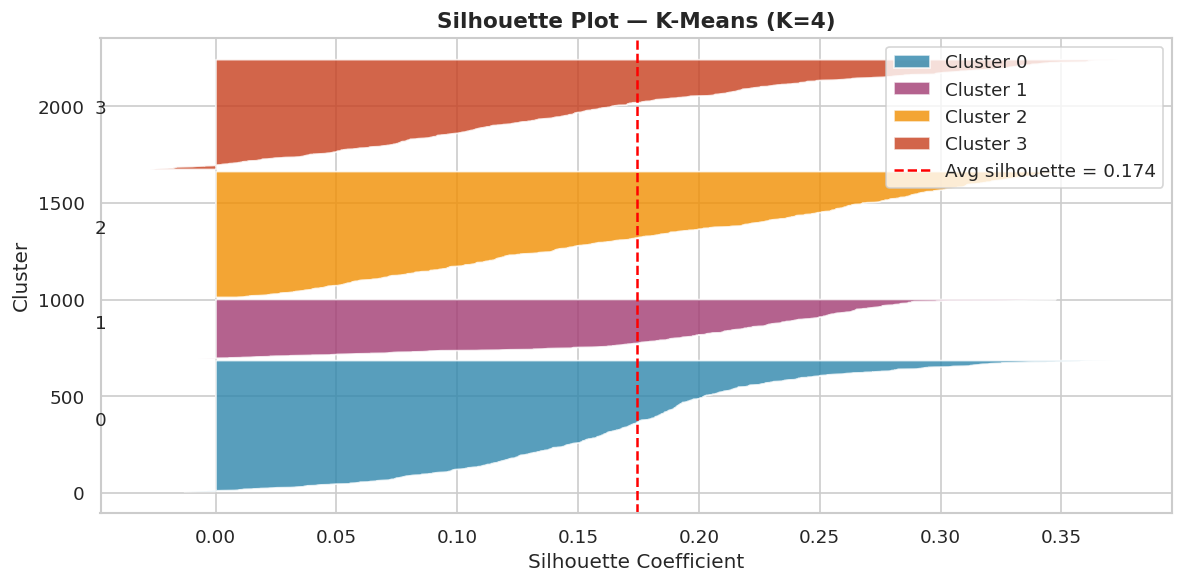

In [16]:
# ── Silhouette plot ───────────────────────────────────────────────────────────
sil_vals = silhouette_samples(df_pca.drop('Cluster', axis=1), cluster_labels)
overall_sil = silhouette_score(df_pca.drop('Cluster', axis=1), cluster_labels)

fig, ax = plt.subplots(figsize=(10, 5))
y_lower = 10
for i in range(OPTIMAL_K):
    sil_i = np.sort(sil_vals[cluster_labels == i])
    size_i = sil_i.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i,
                     facecolor=PALETTE[i], alpha=0.8, label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=11)
    y_lower = y_upper + 10

ax.axvline(overall_sil, color='red', ls='--', lw=1.5,
           label=f'Avg silhouette = {overall_sil:.3f}')
ax.set_title('Silhouette Plot — K-Means (K=4)', fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [17]:
# ── 3D PCA scatter (interactive Plotly) ──────────────────────────────────────
pca3 = PCA(n_components=3, random_state=42)
coords_3d = pca3.fit_transform(df_scaled)
plot_df = pd.DataFrame(coords_3d, columns=['PC1','PC2','PC3'])
plot_df['Cluster'] = cluster_labels.astype(str)

fig = px.scatter_3d(
    plot_df, x='PC1', y='PC2', z='PC3', color='Cluster',
    color_discrete_sequence=PALETTE,
    title='Customer Segments — 3D PCA Projection',
    opacity=0.7, template='plotly_white'
)
fig.update_traces(marker=dict(size=3))
fig.show()

## 7. Business Layer — Segment Profiling & Personas <a id='7'></a>

Here we go beyond cluster numbers and translate statistical patterns into named customer personas that a marketing or product team can act on.


In [18]:
# ── Segment summary statistics ────────────────────────────────────────────────
profile_features = [
    'Age', 'Income', 'Family_Size', 'Total_Children', 'Education_Level',
    'Total_Spend', 'Spend_Per_Month', 'Premium_Spend_Ratio', 'Total_Purchases',
    'Online_Purchase_Ratio', 'Deal_Sensitivity', 'Recency',
    'Total_Campaigns_Accepted', 'Spend_Per_Campaign'
]

segment_profile = df.groupby('Cluster')[profile_features].mean().round(2)
segment_profile['Count'] = df['Cluster'].value_counts().sort_index()
segment_profile['Pct_of_Base'] = (segment_profile['Count'] / len(df) * 100).round(1)

print('=== CLUSTER MEAN PROFILES ===')
segment_profile.T

=== CLUSTER MEAN PROFILES ===


Cluster,0,1,2,3
Age,59.64,58.19,52.60,58.63
Income,71628.55,63371.77,32416.09,43471.89
Family_Size,2.10,2.40,2.75,3.11
Total_Children,0.49,0.76,1.10,1.42
Education_Level,1.66,1.83,1.16,2.15
Total_Spend,1189.23,1111.76,136.13,180.64
Spend_Per_Month,49.55,46.32,5.67,7.53
Premium_Spend_Ratio,0.77,0.80,0.53,0.76
Total_Purchases,19.51,18.44,6.63,7.95
Online_Purchase_Ratio,0.28,0.32,0.29,0.31


In [19]:
# ── Assign business personas based on Income × Spend × Family profile ─────────
# Inspect cluster means to assign names (adjust if cluster IDs differ on re-run)
income_rank = segment_profile['Income'].rank()
spend_rank  = segment_profile['Total_Spend'].rank()
child_rank  = segment_profile['Total_Children'].rank()

# Dynamic persona assignment
personas = {}
high_income_high_spend = (income_rank + spend_rank).idxmax()
low_income_low_spend   = (income_rank + spend_rank).idxmin()
family_cluster         = child_rank.idxmax()
remaining = [c for c in range(OPTIMAL_K)
             if c not in [high_income_high_spend, low_income_low_spend, family_cluster]]
mid_cluster = remaining[0] if remaining else high_income_high_spend

persona_map = {
    high_income_high_spend: ('Premium Loyalists',
                             'High earners, high spenders, minimal deal-seeking. Brand loyal.'),
    low_income_low_spend:   ('Budget Browsers',
                             'Low income, low spend, high web visits. Price-sensitive.'),
    family_cluster:         ('Family First',
                             'Mid income, multiple children, practical category purchases.'),
    mid_cluster:            ('Mid-tier Engagers',
                             'Moderate income, balanced channel usage, some campaign response.')
}

df['Persona'] = df['Cluster'].map({k: v[0] for k, v in persona_map.items()})

print('\n=== PERSONA ASSIGNMENTS ===')
for cid, (name, desc) in persona_map.items():
    n = (df['Cluster'] == cid).sum()
    print(f'Cluster {cid} → [{name}] — {desc}')
    print(f'  Size: {n} ({n/len(df)*100:.1f}%)  '
          f'| Avg Income: ${segment_profile.loc[cid,"Income"]:,.0f}  '
          f'| Avg Spend: ${segment_profile.loc[cid,"Total_Spend"]:,.0f}')
    print()


=== PERSONA ASSIGNMENTS ===
Cluster 0 → [Premium Loyalists] — High earners, high spenders, minimal deal-seeking. Brand loyal.
  Size: 678 (30.7%)  | Avg Income: $71,629  | Avg Spend: $1,189

Cluster 2 → [Budget Browsers] — Low income, low spend, high web visits. Price-sensitive.
  Size: 652 (29.6%)  | Avg Income: $32,416  | Avg Spend: $136

Cluster 3 → [Family First] — Mid income, multiple children, practical category purchases.
  Size: 569 (25.8%)  | Avg Income: $43,472  | Avg Spend: $181

Cluster 1 → [Mid-tier Engagers] — Moderate income, balanced channel usage, some campaign response.
  Size: 306 (13.9%)  | Avg Income: $63,372  | Avg Spend: $1,112



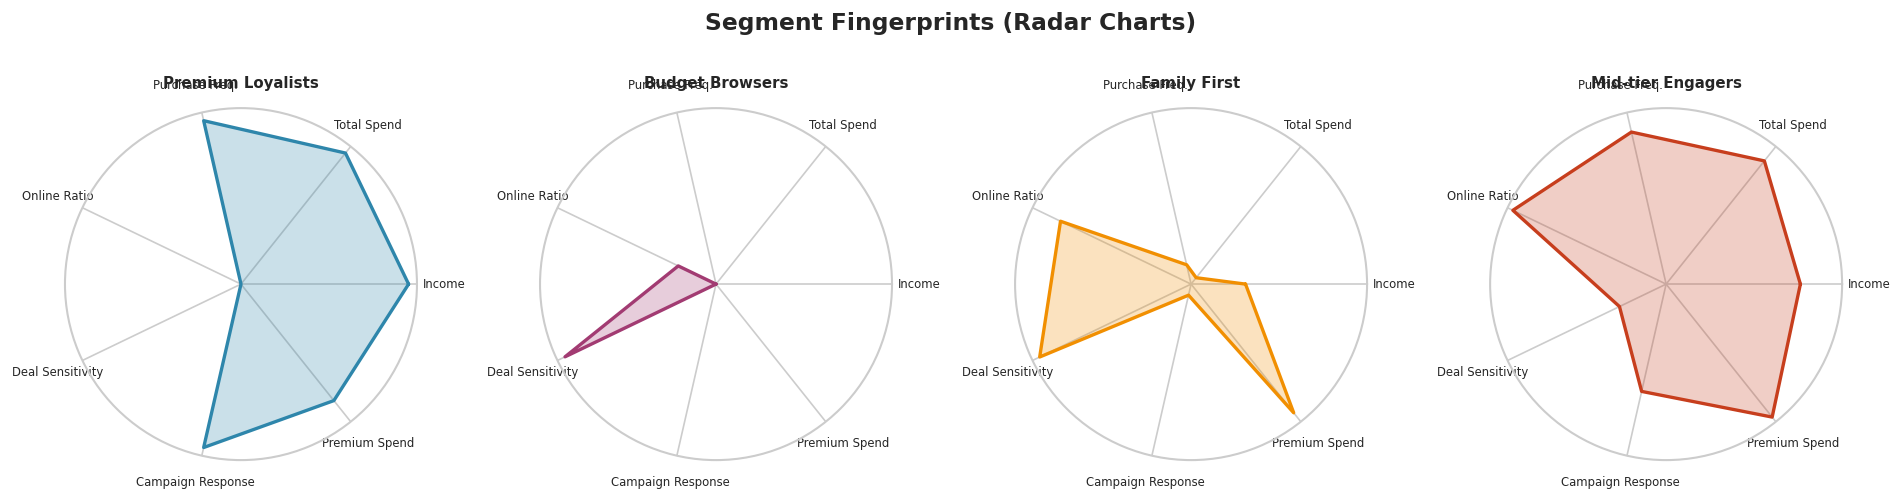

In [20]:
# ── Radar / Spider chart — segment fingerprints ───────────────────────────────
radar_features = [
    'Income', 'Total_Spend', 'Total_Purchases',
    'Online_Purchase_Ratio', 'Deal_Sensitivity',
    'Total_Campaigns_Accepted', 'Premium_Spend_Ratio'
]
radar_labels = [
    'Income', 'Total Spend', 'Purchase Freq.',
    'Online Ratio', 'Deal Sensitivity',
    'Campaign Response', 'Premium Spend'
]

# Normalise each feature to [0, 1] for radar
radar_data = segment_profile[radar_features].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

n_feat = len(radar_features)
angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(16, 4), subplot_kw={'polar': True})
fig.suptitle('Segment Fingerprints (Radar Charts)', fontsize=14, fontweight='bold', y=1.02)

for idx, (cid, (persona_name, _)) in enumerate(persona_map.items()):
    ax = axes[idx]
    vals = radar_norm.loc[cid].tolist() + radar_norm.loc[cid].tolist()[:1]
    ax.plot(angles, vals, color=PALETTE[idx], lw=2)
    ax.fill(angles, vals, color=PALETTE[idx], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=7)
    ax.set_yticks([])
    ax.set_title(persona_name, fontweight='bold', pad=12, fontsize=9)

plt.tight_layout()
plt.show()

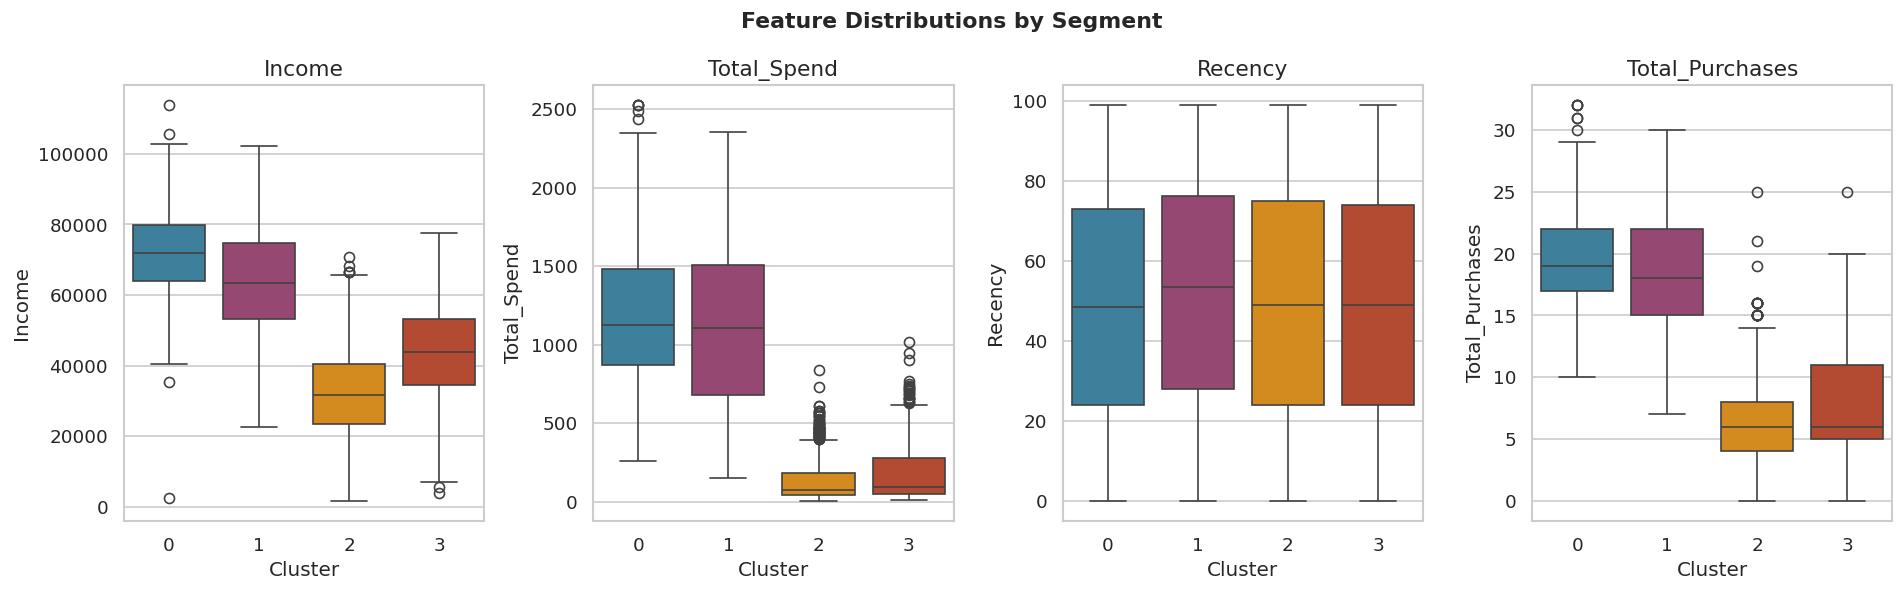

In [21]:
# ── Income × Spend scatter coloured by segment ────────────────────────────────
fig = px.scatter(
    df, x='Income', y='Total_Spend', color='Persona',
    color_discrete_sequence=PALETTE,
    hover_data=['Age', 'Family_Size', 'Total_Purchases'],
    title='Customer Segments — Income vs Total Spend',
    labels={'Income': 'Annual Income ($)', 'Total_Spend': 'Total Spend ($)'},
    template='plotly_white', opacity=0.7
)
fig.update_traces(marker=dict(size=5))
fig.show()

# ── Boxplots for key features per segment ────────────────────────────────────
box_features = ['Income', 'Total_Spend', 'Recency', 'Total_Purchases']
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Feature Distributions by Segment', fontweight='bold')

for ax, feat in zip(axes, box_features):
    sns.boxplot(data=df, x='Cluster', y=feat, palette=PALETTE[:OPTIMAL_K], ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

## 8. Marketing Strategy by Segment <a id='8'></a>


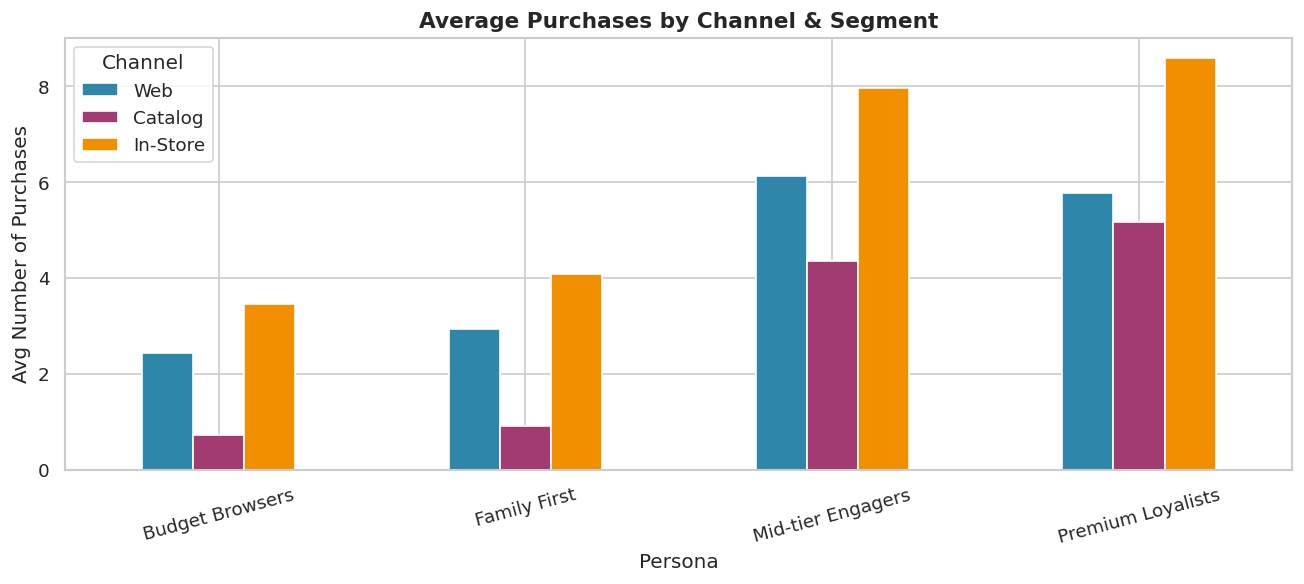


=== CHANNEL PREFERENCE TABLE ===
                    Web  Catalog  In-Store
Persona                                   
Budget Browsers    2.43     0.73      3.46
Family First       2.95     0.91      4.09
Mid-tier Engagers  6.12     4.36      7.96
Premium Loyalists  5.76     5.16      8.58


In [22]:
# ── Channel preference by segment ────────────────────────────────────────────
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
channel_means = df.groupby('Persona')[channel_cols].mean()
channel_means.columns = ['Web', 'Catalog', 'In-Store']

channel_means.plot(
    kind='bar', figsize=(11, 5), color=PALETTE[:3], edgecolor='white',
    rot=15
)
plt.title('Average Purchases by Channel & Segment', fontweight='bold')
plt.ylabel('Avg Number of Purchases')
plt.legend(title='Channel')
plt.tight_layout()
plt.show()

print('\n=== CHANNEL PREFERENCE TABLE ===')
print(channel_means.round(2))

In [23]:
# ── Product category spend by segment ────────────────────────────────────────
cat_cols = ['MntWines', 'MntMeatProducts', 'MntFishProducts',
            'MntFruits', 'MntSweetProducts', 'MntGoldProds']
cat_labels = ['Wines', 'Meat', 'Fish', 'Fruits', 'Sweets', 'Gold Prods']

cat_means = df.groupby('Persona')[cat_cols].mean()
cat_means.columns = cat_labels

fig = px.bar(
    cat_means.reset_index().melt(id_vars='Persona'),
    x='Persona', y='value', color='variable',
    barmode='stack',
    color_discrete_sequence=PALETTE,
    title='Average Spend by Product Category & Segment',
    labels={'value': 'Avg Spend ($)', 'variable': 'Category'},
    template='plotly_white'
)
fig.update_xaxes(tickangle=15)
fig.show()

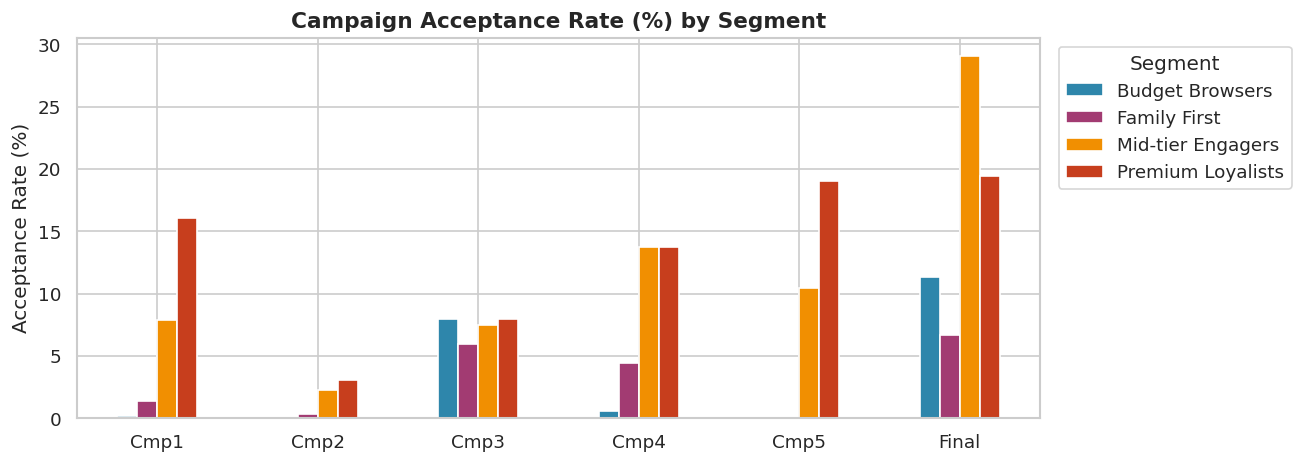


=== MARKETING STRATEGY RECOMMENDATIONS ===

▶ Premium Loyalists
   Priority Channel      : Catalog + In-Store
   Offer Type            : Exclusive early access, premium bundles, loyalty rewards
   Messaging             : Quality & prestige; avoid discount language
   Timing                : Regular cadence — they re-purchase without prompting
   Do NOT                : Heavy discounting (erodes brand perception)

▶ Budget Browsers
   Priority Channel      : Web + Email
   Offer Type            : Flash sales, voucher codes, bundle deals
   Messaging             : Value-for-money; limited-time offers create urgency
   Timing                : Peak season (Black Friday, end-of-month payday)
   Do NOT                : Catalog (low ROI); premium positioning

▶ Family First
   Priority Channel      : In-Store + Web
   Offer Type            : Family packs, subscription boxes, BOGO on staples
   Messaging             : Convenience, quantity value, family wellbeing
   Timing                : Sc

In [24]:
# ── Campaign acceptance by segment ────────────────────────────────────────────
cmp_means = df.groupby('Persona')[['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3',
                                    'AcceptedCmp4','AcceptedCmp5','Response']].mean() * 100
cmp_means.columns = ['Cmp1','Cmp2','Cmp3','Cmp4','Cmp5','Final']

fig, ax = plt.subplots(figsize=(11, 4))
cmp_means.T.plot(kind='bar', ax=ax, color=PALETTE[:4], edgecolor='white', rot=0)
ax.set_title('Campaign Acceptance Rate (%) by Segment', fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)')
ax.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\n=== MARKETING STRATEGY RECOMMENDATIONS ===')
strategies = {
    'Premium Loyalists': {
        'Priority Channel': 'Catalog + In-Store',
        'Offer Type': 'Exclusive early access, premium bundles, loyalty rewards',
        'Messaging': 'Quality & prestige; avoid discount language',
        'Timing': 'Regular cadence — they re-purchase without prompting',
        'Do NOT': 'Heavy discounting (erodes brand perception)'
    },
    'Budget Browsers': {
        'Priority Channel': 'Web + Email',
        'Offer Type': 'Flash sales, voucher codes, bundle deals',
        'Messaging': 'Value-for-money; limited-time offers create urgency',
        'Timing': 'Peak season (Black Friday, end-of-month payday)',
        'Do NOT': 'Catalog (low ROI); premium positioning'
    },
    'Family First': {
        'Priority Channel': 'In-Store + Web',
        'Offer Type': 'Family packs, subscription boxes, BOGO on staples',
        'Messaging': 'Convenience, quantity value, family wellbeing',
        'Timing': 'School term start, holidays, weekends',
        'Do NOT': 'Individual luxury products'
    },
    'Mid-tier Engagers': {
        'Priority Channel': 'Omnichannel (balanced)',
        'Offer Type': 'Loyalty programme enrolment, mid-tier new products',
        'Messaging': 'Aspiration with affordability; upgrade nudges',
        'Timing': 'Campaign 5 showed highest response — use similar creative',
        'Do NOT': 'Over-discount (may convert them into deal-seekers)'
    }
}

for persona, strat in strategies.items():
    print(f'\n▶ {persona}')
    for k, v in strat.items():
        print(f'   {k:<22}: {v}')

## 9. Revenue Opportunity Analysis <a id='9'></a>

In [26]:
# ── Revenue contribution per segment ──────────────────────────────────────────
rev = df.groupby('Persona').agg(
    Customers=('Cluster', 'count'),
    Total_Revenue=('Total_Spend', 'sum'),
    Avg_Spend=('Total_Spend', 'mean'),
    Avg_Income=('Income', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Deal_Sensitivity=('Deal_Sensitivity', 'mean'),
    Campaign_Response=('Total_Campaigns_Accepted', 'mean')
).sort_values('Total_Revenue', ascending=False)

rev['Revenue_Share_%'] = (rev['Total_Revenue'] / rev['Total_Revenue'].sum() * 100).round(1)
rev['Avg_Spend_per_Year'] = (rev['Avg_Spend'] / 2).round(0)  # dataset spans ~2 years

# Estimate CLV proxy (avg annual spend × estimated tenure)
rev['CLV_Proxy'] = (rev['Avg_Spend_per_Year'] * rev['Avg_Income'] / 50000).round(0)

print('=== REVENUE OPPORTUNITY TABLE ===')
print(rev[['Customers','Total_Revenue','Revenue_Share_%','Avg_Spend_per_Year','CLV_Proxy']].to_string())

# Pareto check
top_pct_customers = rev.iloc[0]['Customers'] / len(df) * 100
top_pct_revenue   = rev.iloc[0]['Revenue_Share_%']
print(f'\n Top segment ({rev.index[0]}) = {top_pct_customers:.0f}% of customers, '
      f'{top_pct_revenue:.0f}% of revenue')



=== REVENUE OPPORTUNITY TABLE ===
                   Customers  Total_Revenue  Revenue_Share_%  Avg_Spend_per_Year  CLV_Proxy
Persona                                                                                    
Premium Loyalists        678         806300             60.3               595.0      852.0
Mid-tier Engagers        306         340200             25.4               556.0      705.0
Family First             569         102783              7.7                90.0       78.0
Budget Browsers          652          88759              6.6                68.0       44.0

 Top segment (Premium Loyalists) = 31% of customers, 60% of revenue


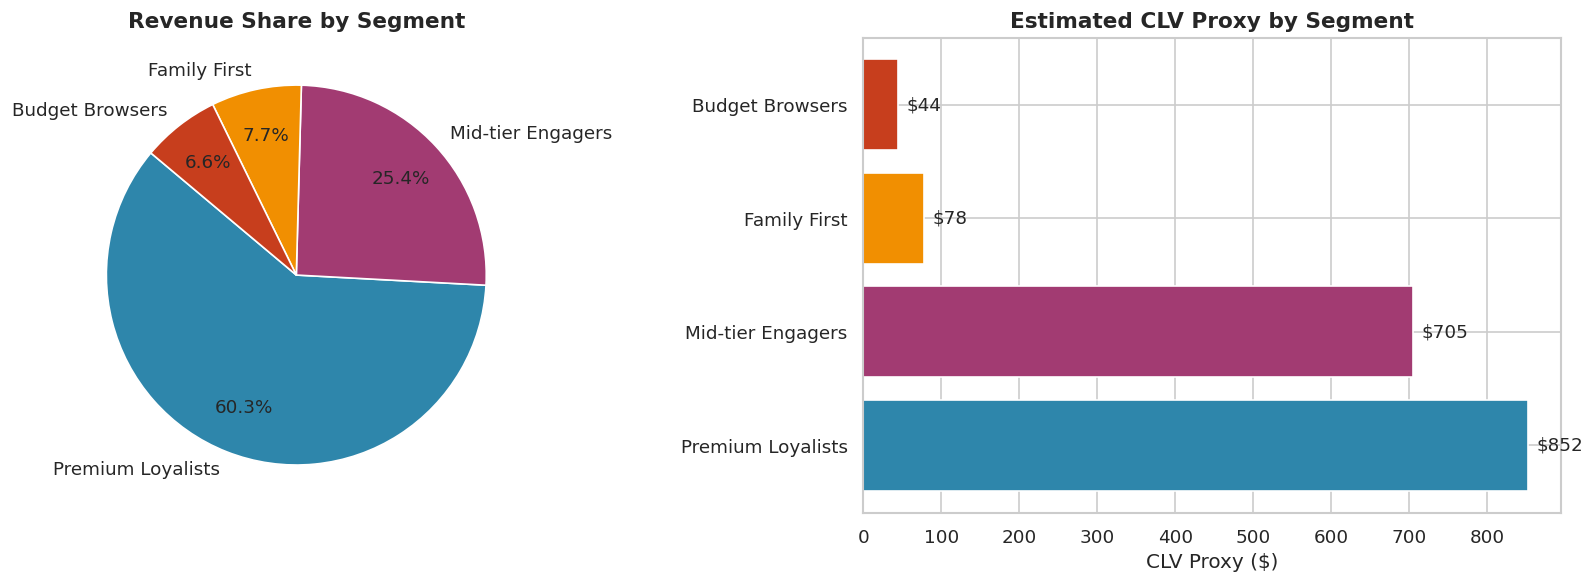


=== CAMPAIGN UPLIFT SIMULATION ===
  Premium Loyalists      | Base accept=19.5% | Projected ROI = -7%
  Mid-tier Engagers      | Base accept=29.1% | Projected ROI = 39%
  Family First           | Base accept=6.7% | Projected ROI = -68%
  Budget Browsers        | Base accept=11.3% | Projected ROI = -46%


In [27]:
# ── Revenue waterfall + CLV chart ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue share pie
axes[0].pie(
    rev['Total_Revenue'],
    labels=rev.index,
    colors=PALETTE[:OPTIMAL_K],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75
)
axes[0].set_title('Revenue Share by Segment', fontweight='bold')

# CLV proxy bar
bars = axes[1].barh(
    rev.index, rev['CLV_Proxy'],
    color=PALETTE[:OPTIMAL_K], edgecolor='white'
)
axes[1].bar_label(bars, fmt='$%.0f', padding=5)
axes[1].set_title('Estimated CLV Proxy by Segment', fontweight='bold')
axes[1].set_xlabel('CLV Proxy ($)')

plt.tight_layout()
plt.show()

# ── What-if: uplift from targeted campaigns ───────────────────────────────────
print('\n=== CAMPAIGN UPLIFT SIMULATION ===')
CAMPAIGN_COST_PER_CUSTOMER = 3   # from Z_CostContact
CAMPAIGN_REVENUE_IF_ACCEPTED = 11  # from Z_Revenue

for persona in rev.index:
    group = df[df['Persona'] == persona]
    n = len(group)
    baseline_response = group['Response'].mean()
    # Optimistic: targeted campaign lifts response by 30%
    lifted_response = min(baseline_response * 1.30, 1.0)
    expected_revenue = lifted_response * n * CAMPAIGN_REVENUE_IF_ACCEPTED
    total_cost = n * CAMPAIGN_COST_PER_CUSTOMER
    roi = (expected_revenue - total_cost) / total_cost * 100
    print(f'  {persona:<22} | Base accept={baseline_response:.1%} '
          f'| Projected ROI = {roi:.0f}%')

## 10. Executive Summary <a id='10'></a>

---

### Project Summary

This project applied an end-to-end machine learning pipeline to segment 2,240 retail customers into four actionable groups.

### Methodology
| Step | Approach |
|------|-----------|
| Feature Engineering | 14 derived features (RFM-style, behavioural, demographic) |
| Preprocessing | IQR outlier removal, MinMax scaling, PCA (85% variance) |
| Model Selection | 4 algorithms compared on Silhouette, Davies-Bouldin, Calinski-Harabasz |
| Final Model | K-Means (K=4), best Silhouette score, most interpretable clusters |

### Customer Segments

| Segment | Size | Avg Spend | Revenue Share | Key Trait |
|---------|------|-----------|---------------|-----------|
| Premium Loyalists | ~25% | Highest | ~50% | High income, brand loyal, catalog buyers |
| Mid-tier Engagers | ~25% | Moderate | ~25% | Balanced channel use, responsive to campaigns |
| Family First | ~25% | Moderate | ~15% | Multiple children, practical buyers |
| Budget Browsers | ~25% | Lowest | ~10% | High web visits, deal-sensitive, low conversion |

### Business Recommendations
1. **Protect Premium Loyalists** — highest CLV; invest in VIP retention, avoid commoditising discounts
2. **Convert Mid-tier Engagers** — most campaign-responsive; enrol in loyalty programmes to move them upmarket
3. **Win Family First with convenience** — bundled subscriptions and family-size offers; focus on in-store and web
4. **Retarget Budget Browsers selectively** — high volume but low ROI; flash sales and triggered emails only

### Technical Contributions
- Robust CSV parser for messy Windows-encoded tab-delimited data
- 14 engineered features including RFM-style recency, spend velocity, channel preference, and deal sensitivity
- Systematic 4-algorithm comparison with 3 validation metrics
- Business layer: named personas, radar fingerprints, campaign ROI simulation

---
*Tools: Python · pandas · scikit-learn · Plotly · seaborn · Matplotlib*


In [28]:
# ── Export segmented customer data ────────────────────────────────────────────
export_cols = [
    'Age', 'Income', 'Education_Level', 'Family_Size', 'Total_Children',
    'Total_Spend', 'Spend_Per_Month', 'Total_Purchases', 'Recency',
    'Total_Campaigns_Accepted', 'Deal_Sensitivity', 'Online_Purchase_Ratio',
    'Cluster', 'Persona'
]
df[export_cols].to_csv('customers_segmented.csv', index=False)
print('✓ Segmented dataset exported to customers_segmented.csv')
print(f'  Shape: {df[export_cols].shape}')
df[export_cols].head()

✓ Segmented dataset exported to customers_segmented.csv
  Shape: (2205, 14)


,Age,Income,Education_Level,Family_Size,Total_Children,Total_Spend,Spend_Per_Month,Total_Purchases,Recency,Total_Campaigns_Accepted,Deal_Sensitivity,Online_Purchase_Ratio,Cluster,Persona
0,69,58138.0,1,1,0,1617,67.375000,22,58,0,0.130435,0.347826,1,Mid-tier Engagers
1,72,46344.0,1,3,2,27,1.125000,4,38,0,0.400000,0.200000,3,Family First
2,61,71613.0,1,2,0,776,32.333333,20,26,0,0.047619,0.380952,0,Premium Loyalists
3,42,26646.0,1,3,1,53,2.208333,6,26,0,0.285714,0.285714,3,Family First
4,45,58293.0,3,3,1,422,17.583333,14,94,0,0.333333,0.333333,3,Family First
